# Giant Otter Call-Type Classifier

Classify 21 call types from Amazonian giant otters (*Pteronura brasiliensis*) using BEATs and EfficientNet-B0 audio embeddings.

**Workflow:** download → explore → embed (BEATs last-layer, BEATs all-layers avg, EfficientNet) → UMAP → training-free metrics (NMI, ARI, R-AUC) → linear probe → attention probe (sl-BEATs embeddings) → save artifacts.

In [1]:
import pathlib
import sys


def find_repo_root(start: pathlib.Path) -> pathlib.Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists():
            return p
    raise FileNotFoundError("Could not locate repo root (pyproject.toml not found).")


REPO_ROOT = find_repo_root(pathlib.Path().resolve())
sys.path.insert(0, str(REPO_ROOT))

import json
import zipfile
from pathlib import Path
from urllib.request import urlretrieve

import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import soundfile as sf
import torch
from avex import load_model
from IPython.display import display
from tqdm.auto import tqdm

from utils.probing import compute_training_free_metrics, run_attention_probe, run_linear_probe
from utils.visualization import (
    confusion_heatmap_static,
    horizontal_counts_bar_static,
    plot_model_comparison,
    plot_model_comparison_static,
    plot_umap,
    plot_umap_static,
)

EXAMPLE_DIR = REPO_ROOT / "examples" / "01_giant_otter_classifier"
DATA_DIR = EXAMPLE_DIR / "data" / "giant_otter"
AUDIO_DIR = DATA_DIR / "audio"
EMBED_DIR = EXAMPLE_DIR / "data" / "embeddings"
EMBED_DIR.mkdir(parents=True, exist_ok=True)

DATASET_URL = "https://archive.org/download/giant_otters/giant_otters.zip"
TARGET_SR = 16_000
WINDOW_SECONDS = 3.0
DEVICE = "cpu"
BEATS_MODEL = "esp_aves2_sl_beats_all"
EFFNET_MODEL = "esp_aves2_effnetb0_all"
print("Setup complete.")

2026-04-16 15:42:27.422380: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-04-16 15:42:29.275071: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Setup complete.


## 1. Download Dataset

In [2]:
def download_dataset(url: str, audio_dir: Path) -> None:
    if audio_dir.exists() and any(audio_dir.rglob("*.wav")):
        print(f"Dataset already present at {audio_dir}")
        return
    audio_dir.mkdir(parents=True, exist_ok=True)
    zip_path = audio_dir / "dataset.zip"
    print(f"Downloading from {url} ...")
    urlretrieve(url, zip_path)
    print("Extracting ...")
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(audio_dir)
    zip_path.unlink()
    print("Done.")


download_dataset(DATASET_URL, AUDIO_DIR)

Dataset already present at /home/marius_miron_earthspecies_org/code/avex-examples/examples/01_giant_otter_classifier/data/giant_otter/audio


## 2. Data Exploration

In [3]:
def collect_files_and_labels(audio_dir: Path) -> tuple[list[Path], list[str]]:
    files, labels = [], []
    for wav in sorted(audio_dir.rglob("*.wav")):
        if "__MACOSX" in wav.parts or wav.stem.startswith("."):
            continue
        stem = wav.stem
        if "_" in stem:
            files.append(wav)
            labels.append(stem.split("_", 1)[1].lower())
    return files, labels


files, labels = collect_files_and_labels(AUDIO_DIR)
print(f"Found {len(files)} files across {len(set(labels))} call types")

Found 453 files across 30 call types


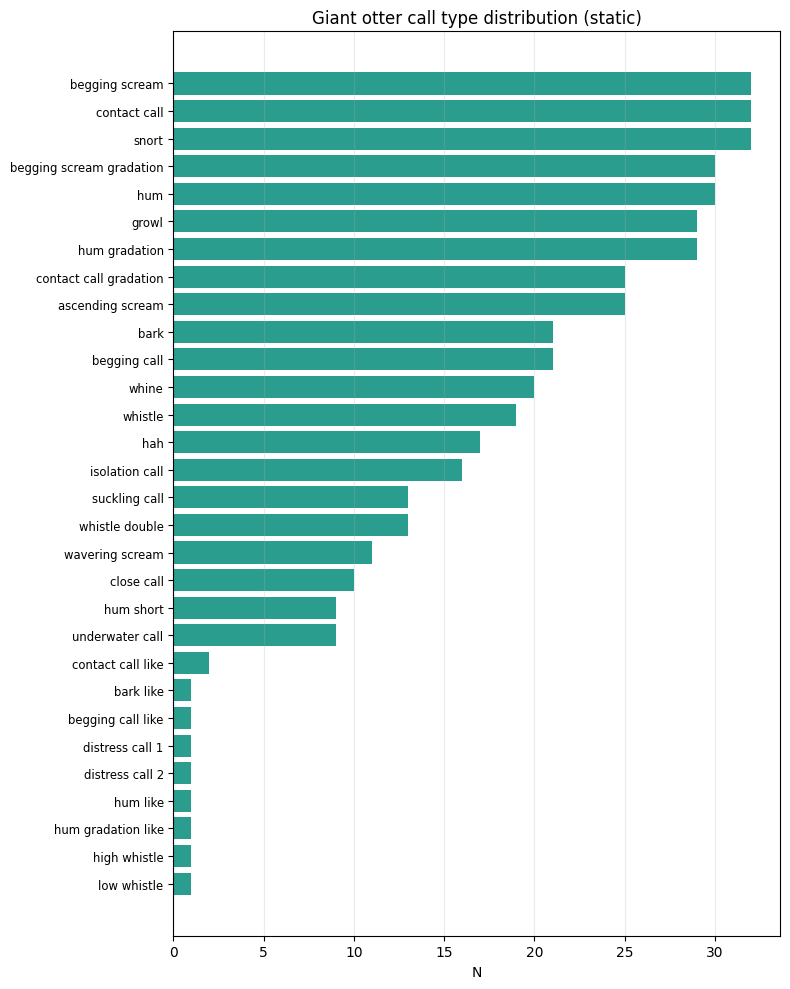

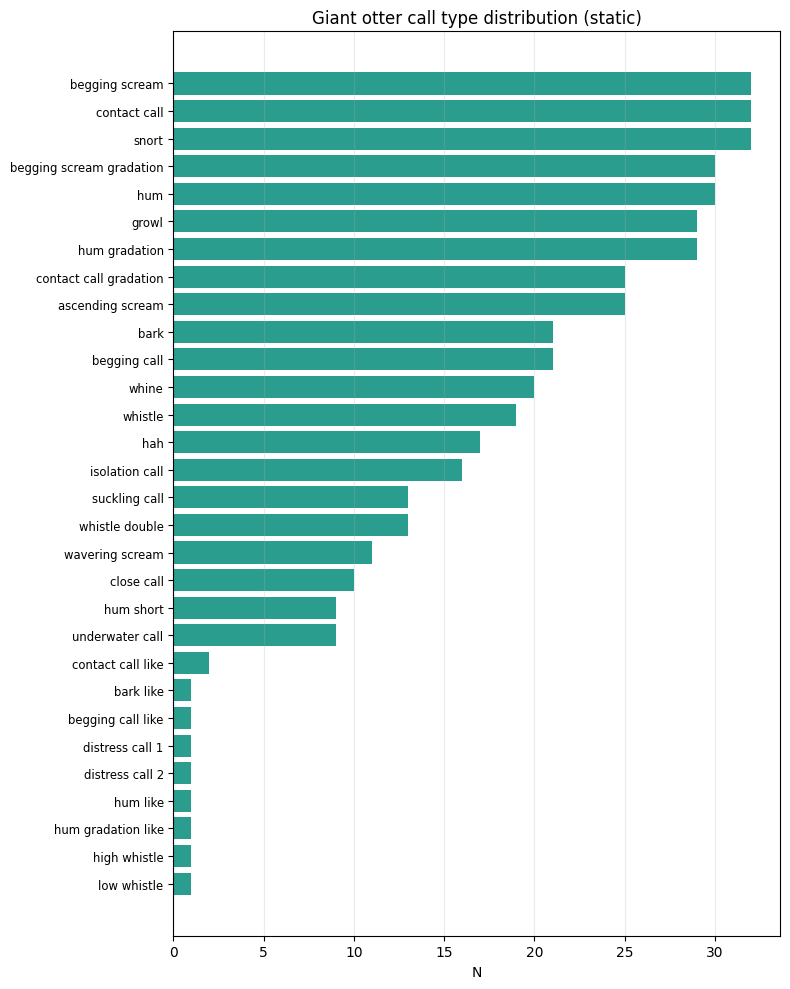

In [4]:
from collections import Counter

counts = Counter(labels)
df_counts = pd.DataFrame(
    sorted(counts.items(), key=lambda x: -x[1]),
    columns=["call_type", "n"],
)
fig = px.bar(
    df_counts,
    x="n",
    y="call_type",
    orientation="h",
    title="Giant otter call type distribution",
    labels={"n": "Number of recordings", "call_type": ""},
    color="n",
    color_continuous_scale="Teal",
    height=600,
)
fig.update_layout(yaxis=dict(autorange="reversed"), showlegend=False)
fig.show()

fig_counts_static = horizontal_counts_bar_static(
    df_counts, x_col="n", y_col="call_type", title="Giant otter call type distribution (static)"
)
display(fig_counts_static)

In [5]:
df = pd.DataFrame({"path": [str(f) for f in files], "call_type": labels})

## 3. Embedding Extraction

We extract three sets of embeddings:
1. **BEATs last layer** — standard mean-pooled output
2. **BEATs all layers (avg)** — mean across all transformer layers, then mean-pooled
3. **EfficientNet-B0** — spatial mean-pooled CNN features

In [6]:
N_SAMPLES = int(WINDOW_SECONDS * TARGET_SR)


def load_audio(path: str, target_sr: int = TARGET_SR) -> torch.Tensor:
    """Load WAV, mono, resample, pad/trim to WINDOW_SECONDS."""
    wav, sr = sf.read(path, dtype="float32", always_2d=True)
    wav = wav.mean(axis=1)
    if sr != target_sr:
        wav = librosa.resample(wav, orig_sr=sr, target_sr=target_sr)
    if len(wav) < N_SAMPLES:
        wav = np.pad(wav, (0, N_SAMPLES - len(wav)))
    else:
        wav = wav[:N_SAMPLES]
    return torch.from_numpy(wav).unsqueeze(0)


print(f"Sample shape: {load_audio(df['path'].iloc[0]).shape}")

Sample shape: torch.Size([1, 48000])


In [7]:
BEATS_CACHE = EMBED_DIR / "beats_embeddings.npy"

if BEATS_CACHE.exists() and np.load(BEATS_CACHE).shape[0] == len(df):
    beats_embs = np.load(BEATS_CACHE)
    print(f"Loaded cached BEATs last-layer embeddings: {beats_embs.shape}")
else:
    print(f"Loading model: {BEATS_MODEL}")
    model = load_model(BEATS_MODEL, return_features_only=True, device=DEVICE)
    model.eval()
    embeddings = []
    with torch.no_grad():
        for path in tqdm(df["path"], desc="BEATs last-layer"):
            wav = load_audio(path)
            feats = model(wav)  # (1, T, 768)
            embeddings.append(feats.mean(dim=1).squeeze(0).cpu().numpy())
    beats_embs = np.stack(embeddings)
    np.save(BEATS_CACHE, beats_embs)
    print(f"Saved BEATs last-layer embeddings: {beats_embs.shape}")
    del model

Loaded cached BEATs last-layer embeddings: (453, 768)


In [8]:
BEATS_ALL_CACHE = EMBED_DIR / "beats_all_layers_embeddings.npy"

if BEATS_ALL_CACHE.exists() and np.load(BEATS_ALL_CACHE).shape[0] == len(df):
    beats_all_embs = np.load(BEATS_ALL_CACHE)
    print(f"Loaded cached BEATs all-layers embeddings: {beats_all_embs.shape}")
else:
    print(f"Loading model for all-layers extraction: {BEATS_MODEL}")
    model = load_model(BEATS_MODEL, return_features_only=True, device=DEVICE)
    model.eval()

    # Register forward hooks on every transformer encoder layer
    try:
        encoder_layers = model.model.encoder.layers
    except AttributeError:
        encoder_layers = model.backbone.encoder.layers
    n_layers = len(encoder_layers)
    layer_store: dict = {}
    hooks = []
    for i, layer in enumerate(encoder_layers):

        def _make_hook(idx):
            def _hook(module, inp, out):
                layer_store[idx] = out[0] if isinstance(out, tuple) else out

            return _hook

        hooks.append(layer.register_forward_hook(_make_hook(i)))
    print(f"  Registered hooks on {n_layers} transformer layers.")

    all_embs = []
    with torch.no_grad():
        for path in tqdm(df["path"], desc="BEATs all-layers"):
            layer_store.clear()
            wav = load_audio(path)
            _ = model(wav)
            # Mean-pool each layer then average across layers → (D,)
            # Handles both time-first (T, B, D) and batch-first (B, T, D) outputs
            per_layer = [
                layer_store[i].view(-1, layer_store[i].shape[-1]).mean(dim=0).cpu().numpy() for i in range(n_layers)
            ]
            all_embs.append(np.mean(per_layer, axis=0))

    for h in hooks:
        h.remove()

    beats_all_embs = np.stack(all_embs)
    np.save(BEATS_ALL_CACHE, beats_all_embs)
    print(f"Saved BEATs all-layers embeddings: {beats_all_embs.shape}")
    del model

Loaded cached BEATs all-layers embeddings: (453, 768)


In [9]:
EFFNET_CACHE = EMBED_DIR / "effnet_embeddings.npy"

if EFFNET_CACHE.exists() and np.load(EFFNET_CACHE).shape[0] == len(df):
    effnet_embs = np.load(EFFNET_CACHE)
    print(f"Loaded cached EfficientNet embeddings: {effnet_embs.shape}")
else:
    print(f"Loading model: {EFFNET_MODEL}")
    model = load_model(EFFNET_MODEL, return_features_only=True, device=DEVICE)
    model.eval()
    embeddings = []
    with torch.no_grad():
        for path in tqdm(df["path"], desc="EfficientNet"):
            wav = load_audio(path)
            feats = model(wav)  # (1, C, H, W)
            embeddings.append(feats.mean(dim=(2, 3)).squeeze(0).cpu().numpy())
    effnet_embs = np.stack(embeddings)
    np.save(EFFNET_CACHE, effnet_embs)
    print(f"Saved EfficientNet embeddings: {effnet_embs.shape}")
    del model

Loaded cached EfficientNet embeddings: (453, 1280)


## 4. UMAP Visualisation

/home/marius_miron_earthspecies_org/code/avex-examples/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/home/marius_miron_earthspecies_org/code/avex-examples/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


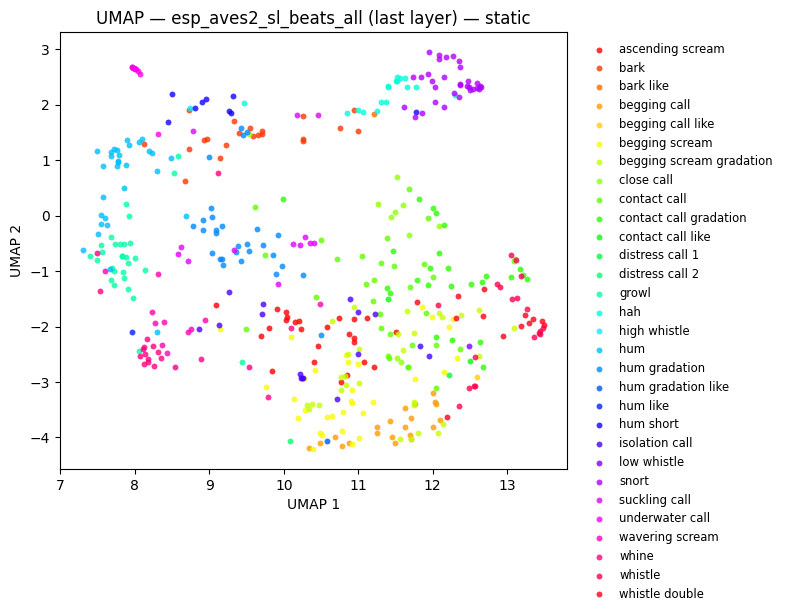

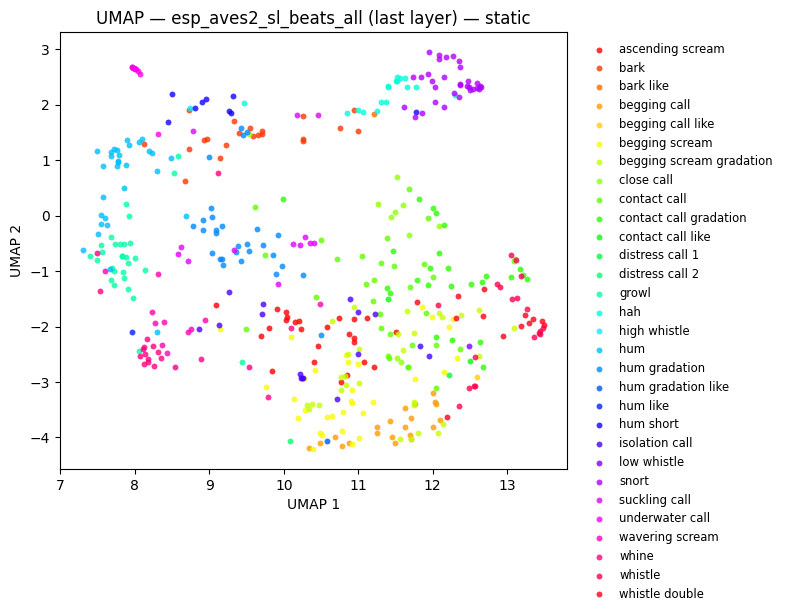

In [10]:
hover = [f"{row['path'].split('/')[-1]}<br>Type: {row['call_type']}" for _, row in df.iterrows()]

fig_beats = plot_umap(beats_embs, labels=labels, title=f"UMAP — {BEATS_MODEL} (last layer)", hover_text=hover)
fig_beats.show()
fig_umap_beats_static = plot_umap_static(beats_embs, labels=labels, title=f"UMAP — {BEATS_MODEL} (last layer) — static")
display(fig_umap_beats_static)

/home/marius_miron_earthspecies_org/code/avex-examples/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/home/marius_miron_earthspecies_org/code/avex-examples/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


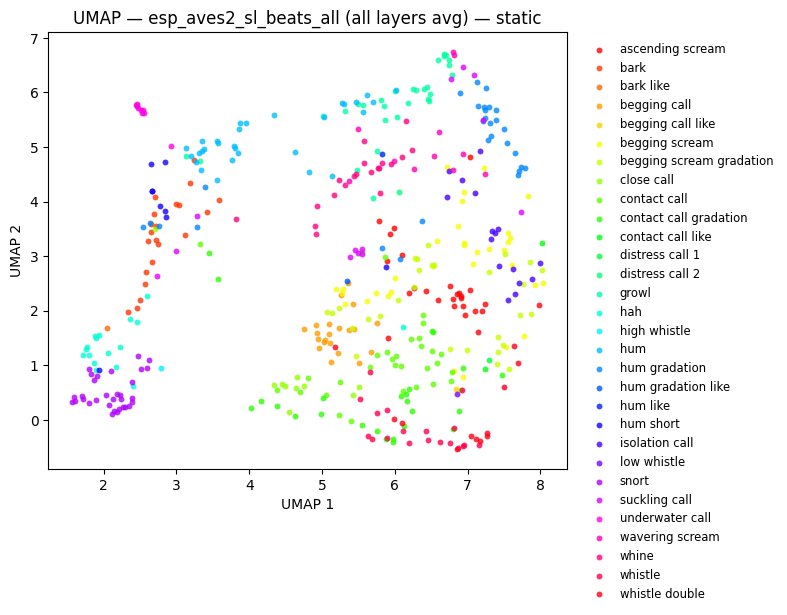

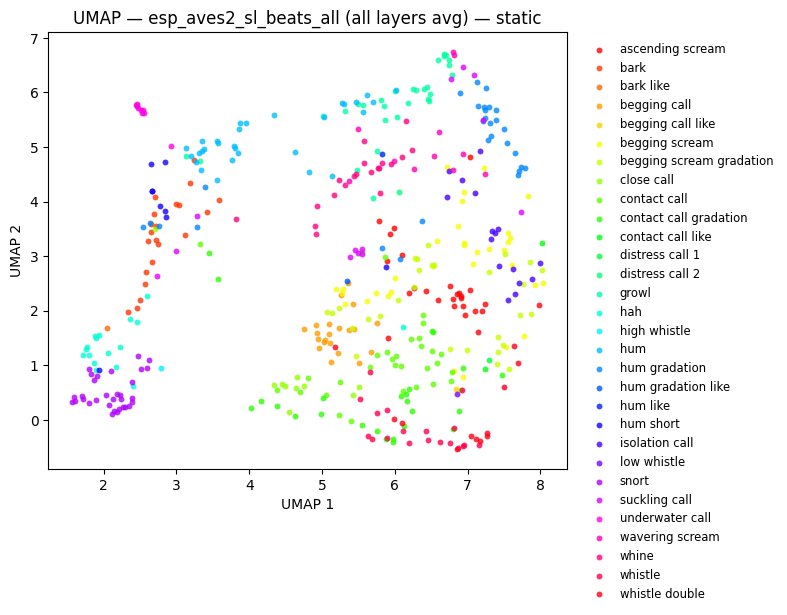

In [11]:
fig_beats_all = plot_umap(
    beats_all_embs, labels=labels, title=f"UMAP — {BEATS_MODEL} (all layers avg)", hover_text=hover
)
fig_beats_all.show()
fig_umap_beats_all_static = plot_umap_static(
    beats_all_embs, labels=labels, title=f"UMAP — {BEATS_MODEL} (all layers avg) — static"
)
display(fig_umap_beats_all_static)

/home/marius_miron_earthspecies_org/code/avex-examples/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/home/marius_miron_earthspecies_org/code/avex-examples/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


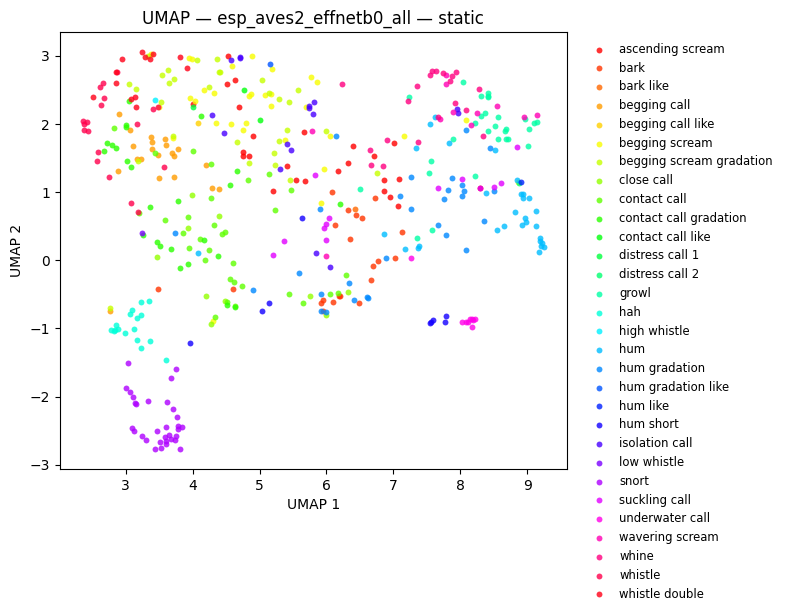

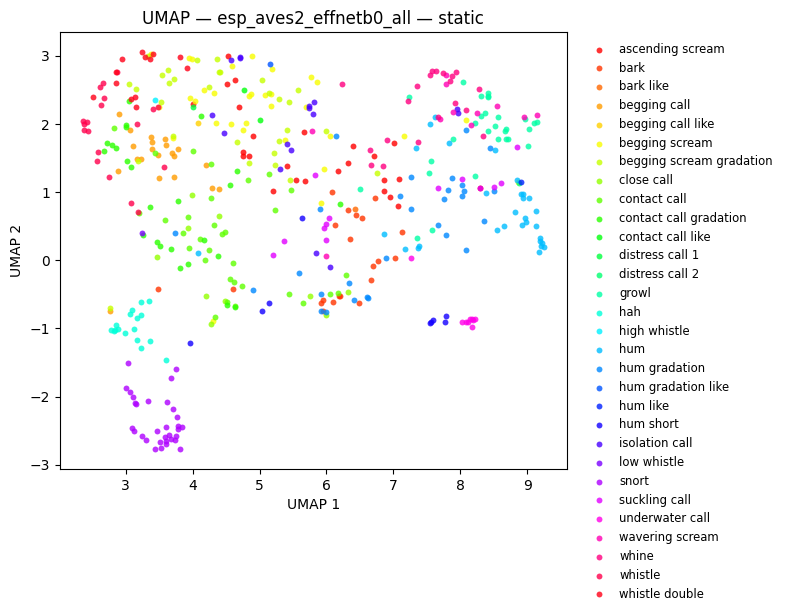

In [12]:
fig_effnet = plot_umap(effnet_embs, labels=labels, title=f"UMAP — {EFFNET_MODEL}", hover_text=hover)
fig_effnet.show()
fig_umap_effnet_static = plot_umap_static(effnet_embs, labels=labels, title=f"UMAP — {EFFNET_MODEL} — static")
display(fig_umap_effnet_static)

## 5. Training-Free Metrics

**NMI** (Normalized Mutual Information) and **ARI** (Adjusted Rand Index) compare k-means cluster assignments to ground-truth labels.
**R-AUC** is the mean average precision for nearest-neighbour retrieval (higher = embeddings of the same class cluster together).

In [13]:
print("Computing training-free metrics (NMI, ARI, R-AUC) ...")
print("These evaluate embedding quality without fitting any classifier.\n")

_labels_for_metrics = labels

_metric_models = [
    (f"{BEATS_MODEL} (last layer)", beats_embs),
    (f"{BEATS_MODEL} (all layers avg)", beats_all_embs),
    (EFFNET_MODEL, effnet_embs),
]

_metric_rows = []
for _name, _embs in _metric_models:
    _m = compute_training_free_metrics(_embs, _labels_for_metrics)
    _metric_rows.append(
        {"Model": _name, "NMI": round(_m["nmi"], 3), "ARI": round(_m["ari"], 3), "R-AUC": round(_m["r_auc"], 3)}
    )
    print(f"  {_name}: NMI={_m['nmi']:.3f}  ARI={_m['ari']:.3f}  R-AUC={_m['r_auc']:.3f}")

_metrics_df = pd.DataFrame(_metric_rows).set_index("Model")
display(_metrics_df)

Computing training-free metrics (NMI, ARI, R-AUC) ...
These evaluate embedding quality without fitting any classifier.



  esp_aves2_sl_beats_all (last layer): NMI=0.607  ARI=0.315  R-AUC=0.368


  esp_aves2_sl_beats_all (all layers avg): NMI=0.619  ARI=0.302  R-AUC=0.383


  esp_aves2_effnetb0_all: NMI=0.550  ARI=0.239  R-AUC=0.342


,NMI,ARI,R-AUC
Model,,,
esp_aves2_sl_beats_all (last layer),0.607,0.315,0.368
esp_aves2_sl_beats_all (all layers avg),0.619,0.302,0.383
esp_aves2_effnetb0_all,0.550,0.239,0.342


## 6. Linear Probe

In [14]:
probe_kwargs = dict(test_size=0.2, random_state=42, max_iter=1000)

probe_results = {}
for name, embs in [
    (f"{BEATS_MODEL} (last layer)", beats_embs),
    (f"{BEATS_MODEL} (all layers avg)", beats_all_embs),
    (EFFNET_MODEL, effnet_embs),
]:
    res = run_linear_probe(embs, labels, **probe_kwargs)
    probe_results[name] = res
    print(f"{name}: accuracy = {res['accuracy']:.3f}")

esp_aves2_sl_beats_all (last layer): accuracy = 0.548


esp_aves2_sl_beats_all (all layers avg): accuracy = 0.561


esp_aves2_effnetb0_all: accuracy = 0.514


/home/marius_miron_earthspecies_org/code/avex-examples/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


## 7. Attention Probe (sl-BEATs)

The avex `AttentionProbe` (`avex.models.probes.AttentionProbe`) stacks multi-head self-attention on frozen mean-pooled BEATs embeddings (`feature_mode=True`).

In [15]:
attn_kwargs = dict(num_heads=8, num_attn_layers=2, epochs=50, test_size=0.2, random_state=42)
attention_results = {}
for name, embs in [
    (f"{BEATS_MODEL} (last layer)", beats_embs),
    (f"{BEATS_MODEL} (all layers avg)", beats_all_embs),
]:
    res = run_attention_probe(embs, labels, **attn_kwargs)
    attention_results[name] = res
    print(f"{name} (attention): accuracy = {res['accuracy']:.3f}")

print("\n--- Linear vs attention (BEATs) ---")
for name in attention_results:
    print(
        f"  {name}: linear={probe_results[name]['accuracy']:.3f}  attention={attention_results[name]['accuracy']:.3f}"
    )

esp_aves2_sl_beats_all (last layer) (attention): accuracy = 0.552


esp_aves2_sl_beats_all (all layers avg) (attention): accuracy = 0.602

--- Linear vs attention (BEATs) ---
  esp_aves2_sl_beats_all (last layer): linear=0.548  attention=0.552
  esp_aves2_sl_beats_all (all layers avg): linear=0.561  attention=0.602


/tmp/ipykernel_189238/3594853299.py:6: RuntimeWarning: invalid value encountered in divide
  cm_norm = (cm / cm.sum(axis=1, keepdims=True) * 100).round(1)


/home/marius_miron_earthspecies_org/code/avex-examples/utils/visualization.py:528: RuntimeWarning: invalid value encountered in divide
  cm_norm = np.where(row_sums > 0, cm.astype(float) / row_sums, 0.0)


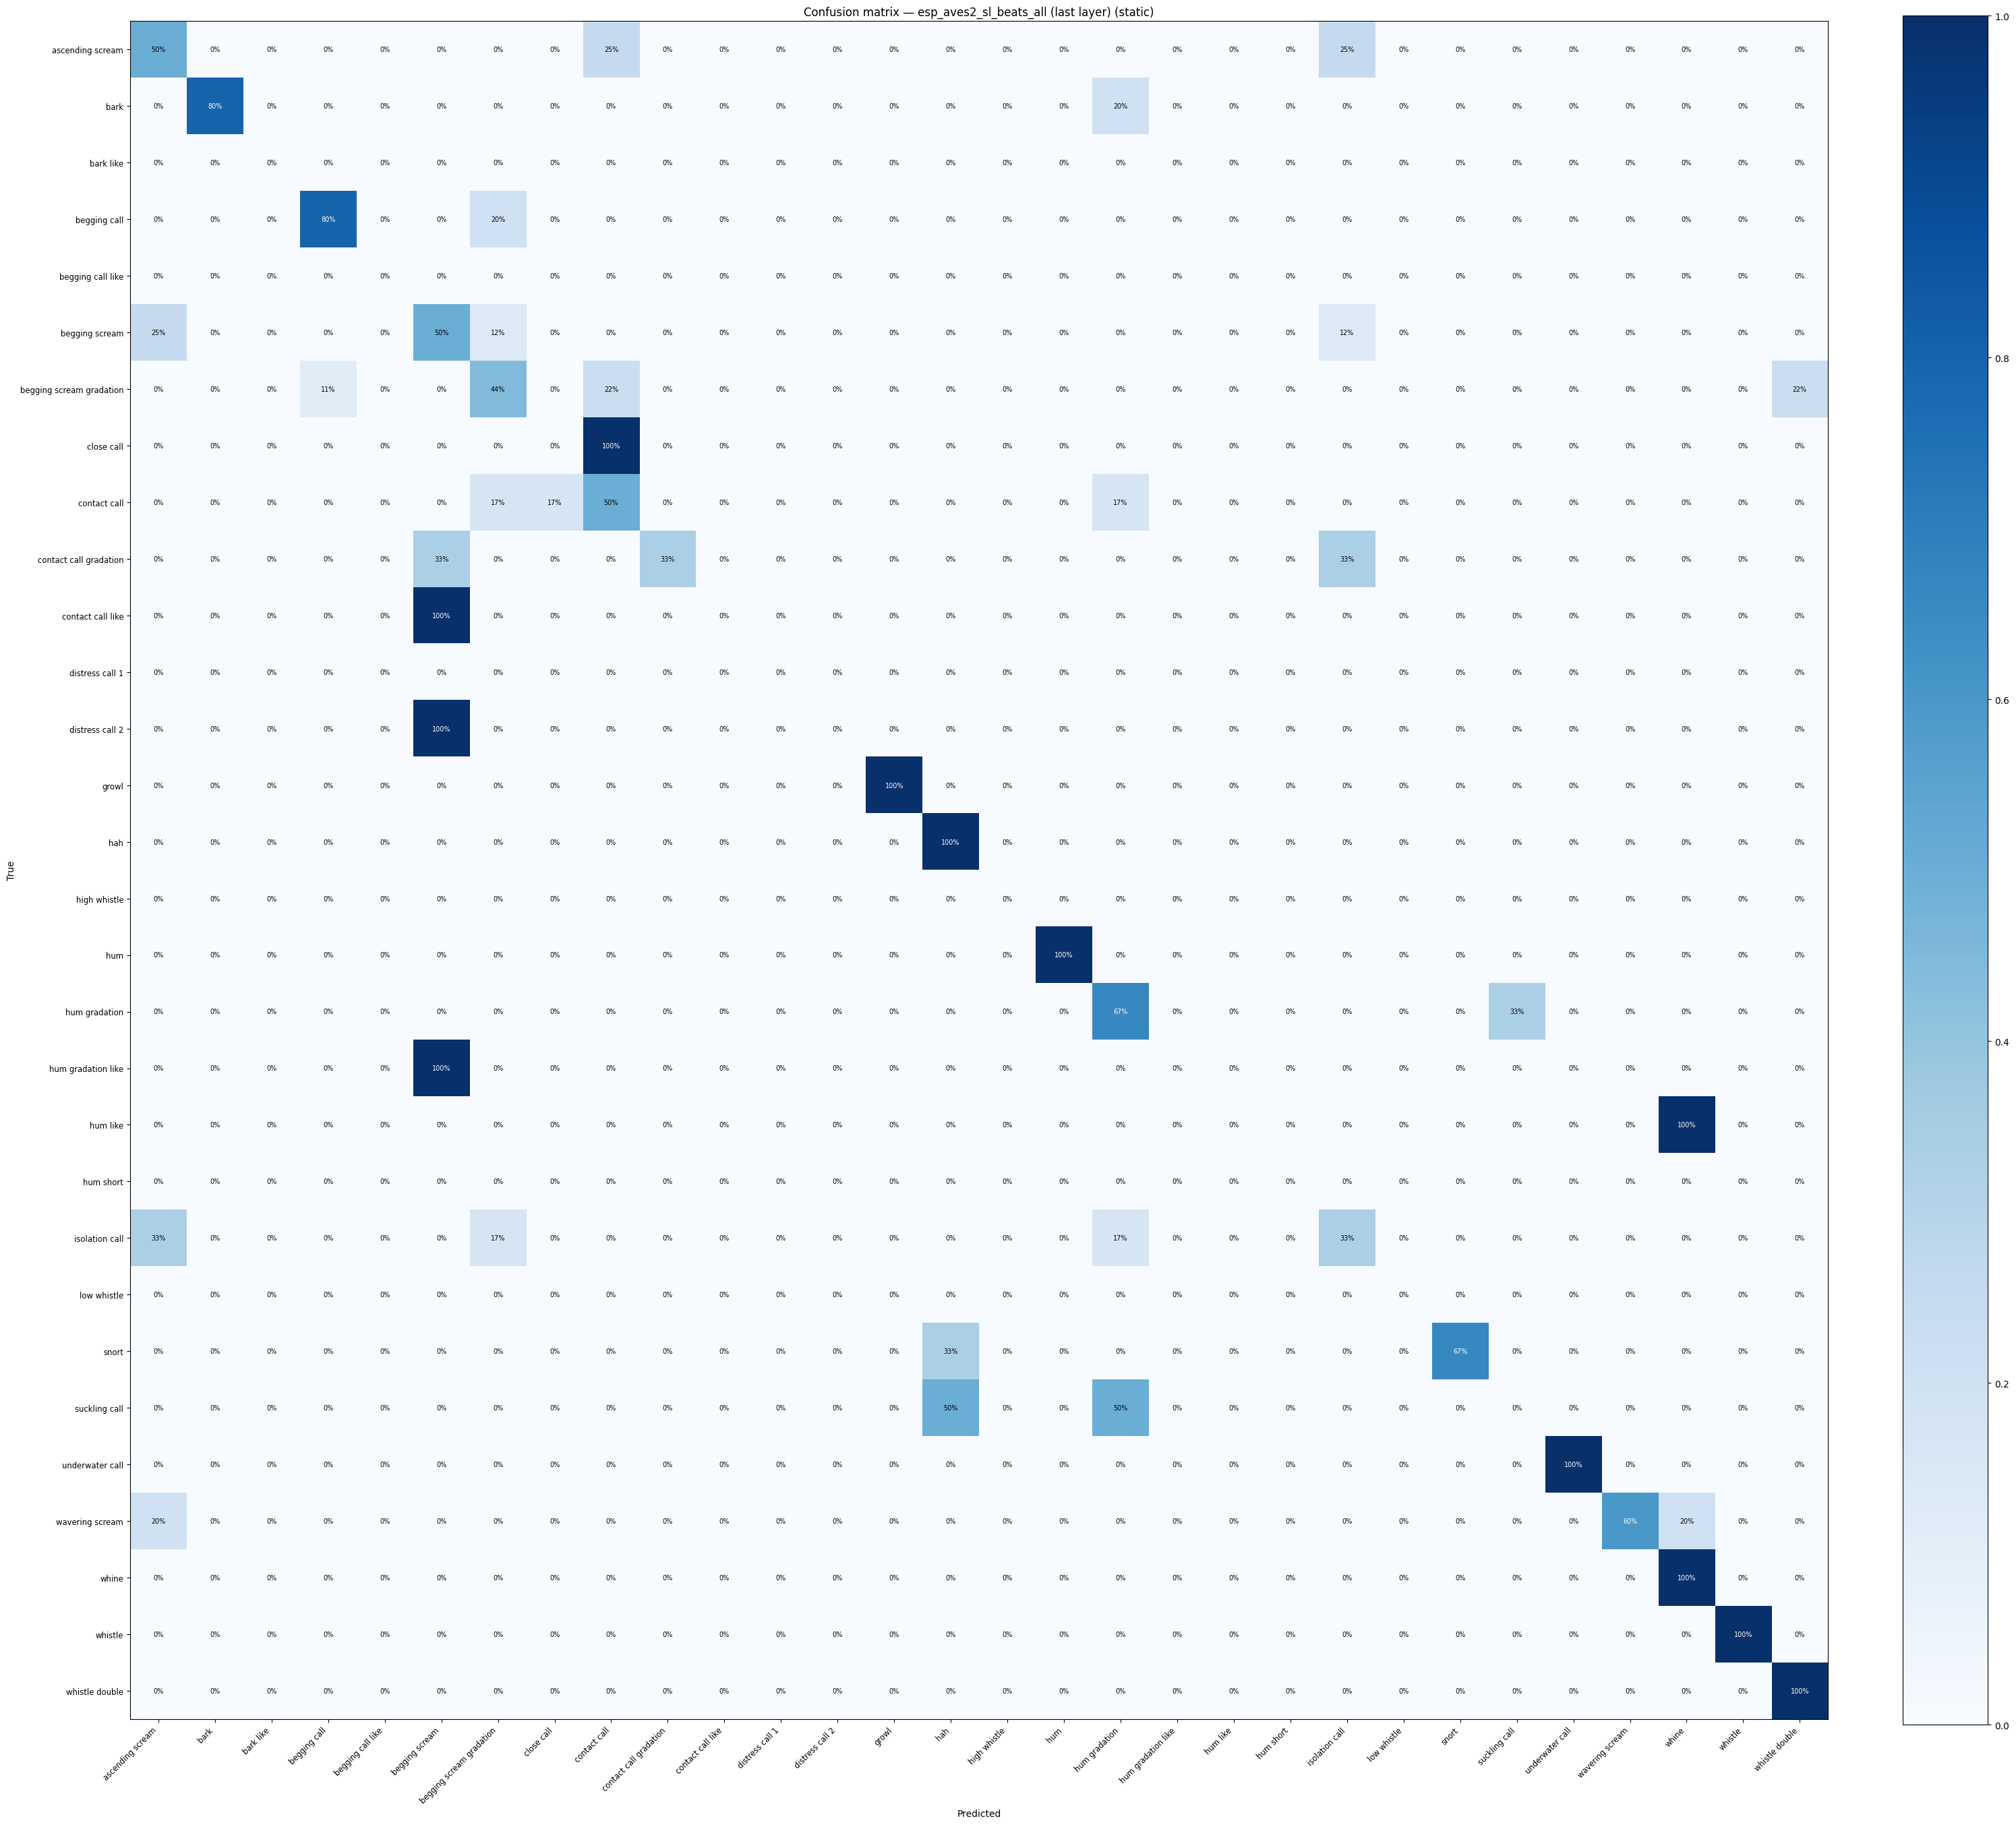

/tmp/ipykernel_189238/3594853299.py:6: RuntimeWarning: invalid value encountered in divide
  cm_norm = (cm / cm.sum(axis=1, keepdims=True) * 100).round(1)


/home/marius_miron_earthspecies_org/code/avex-examples/utils/visualization.py:528: RuntimeWarning: invalid value encountered in divide
  cm_norm = np.where(row_sums > 0, cm.astype(float) / row_sums, 0.0)


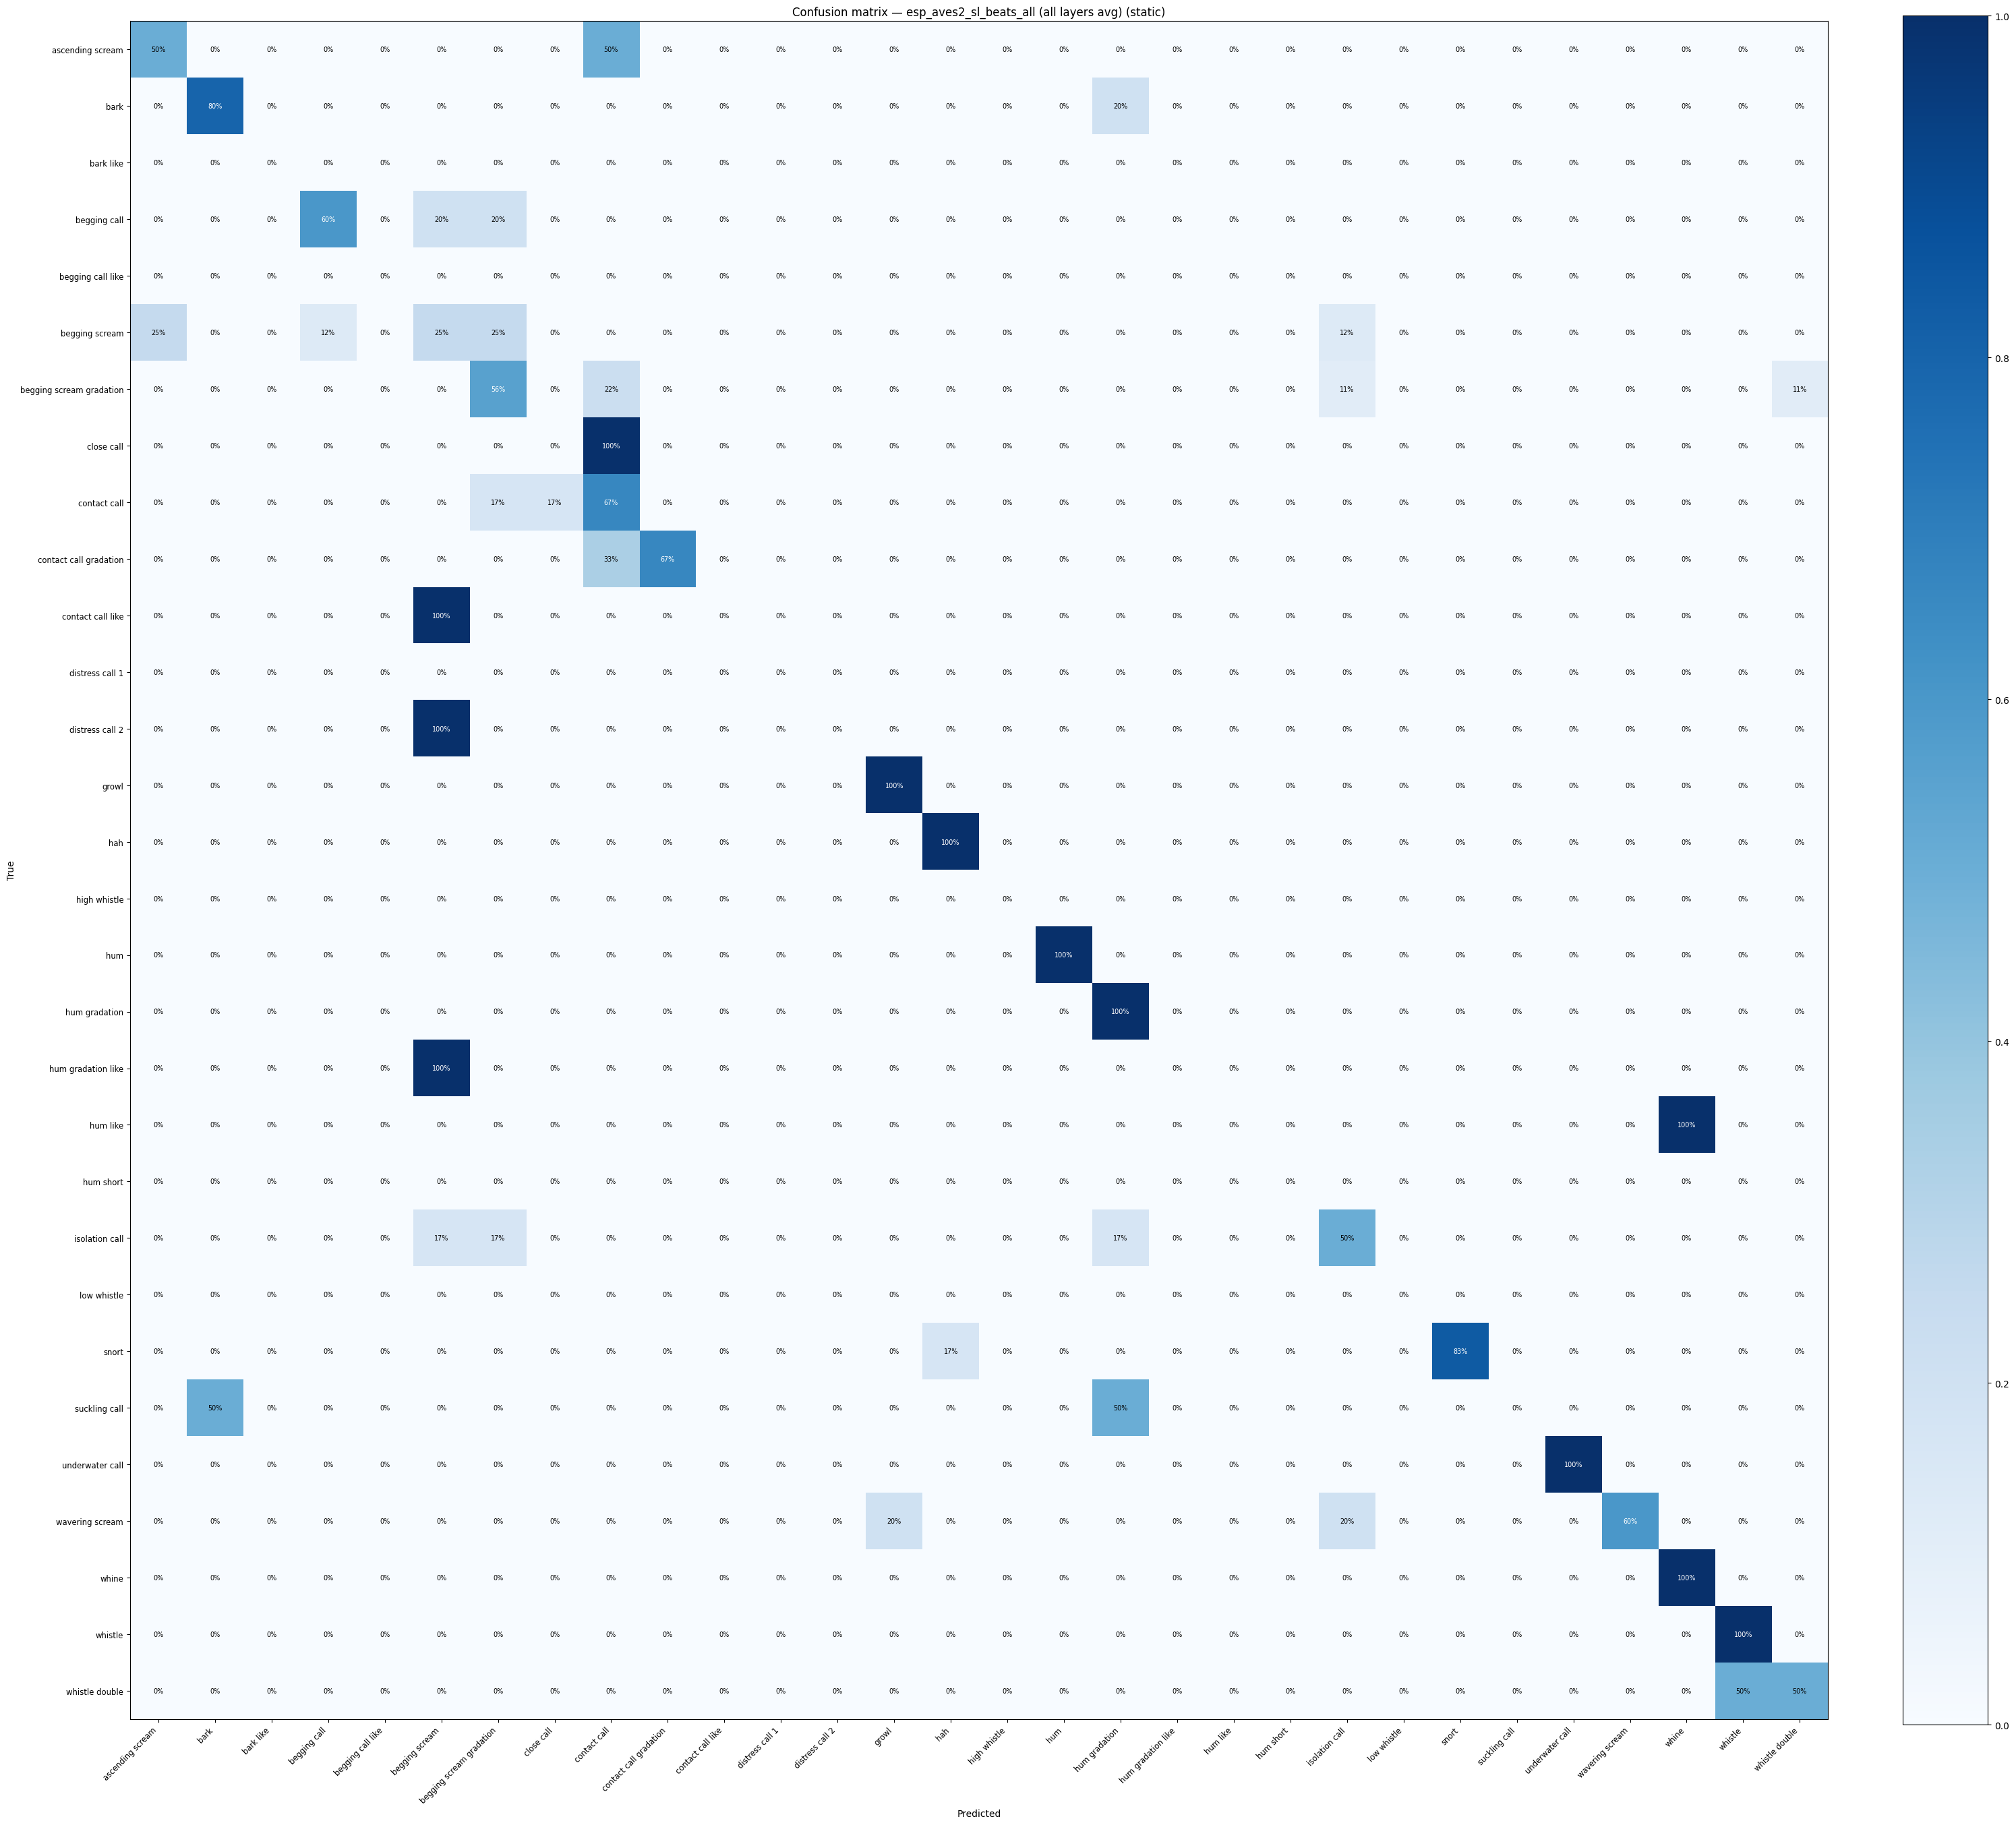

/tmp/ipykernel_189238/3594853299.py:6: RuntimeWarning: invalid value encountered in divide
  cm_norm = (cm / cm.sum(axis=1, keepdims=True) * 100).round(1)


/home/marius_miron_earthspecies_org/code/avex-examples/utils/visualization.py:528: RuntimeWarning: invalid value encountered in divide
  cm_norm = np.where(row_sums > 0, cm.astype(float) / row_sums, 0.0)


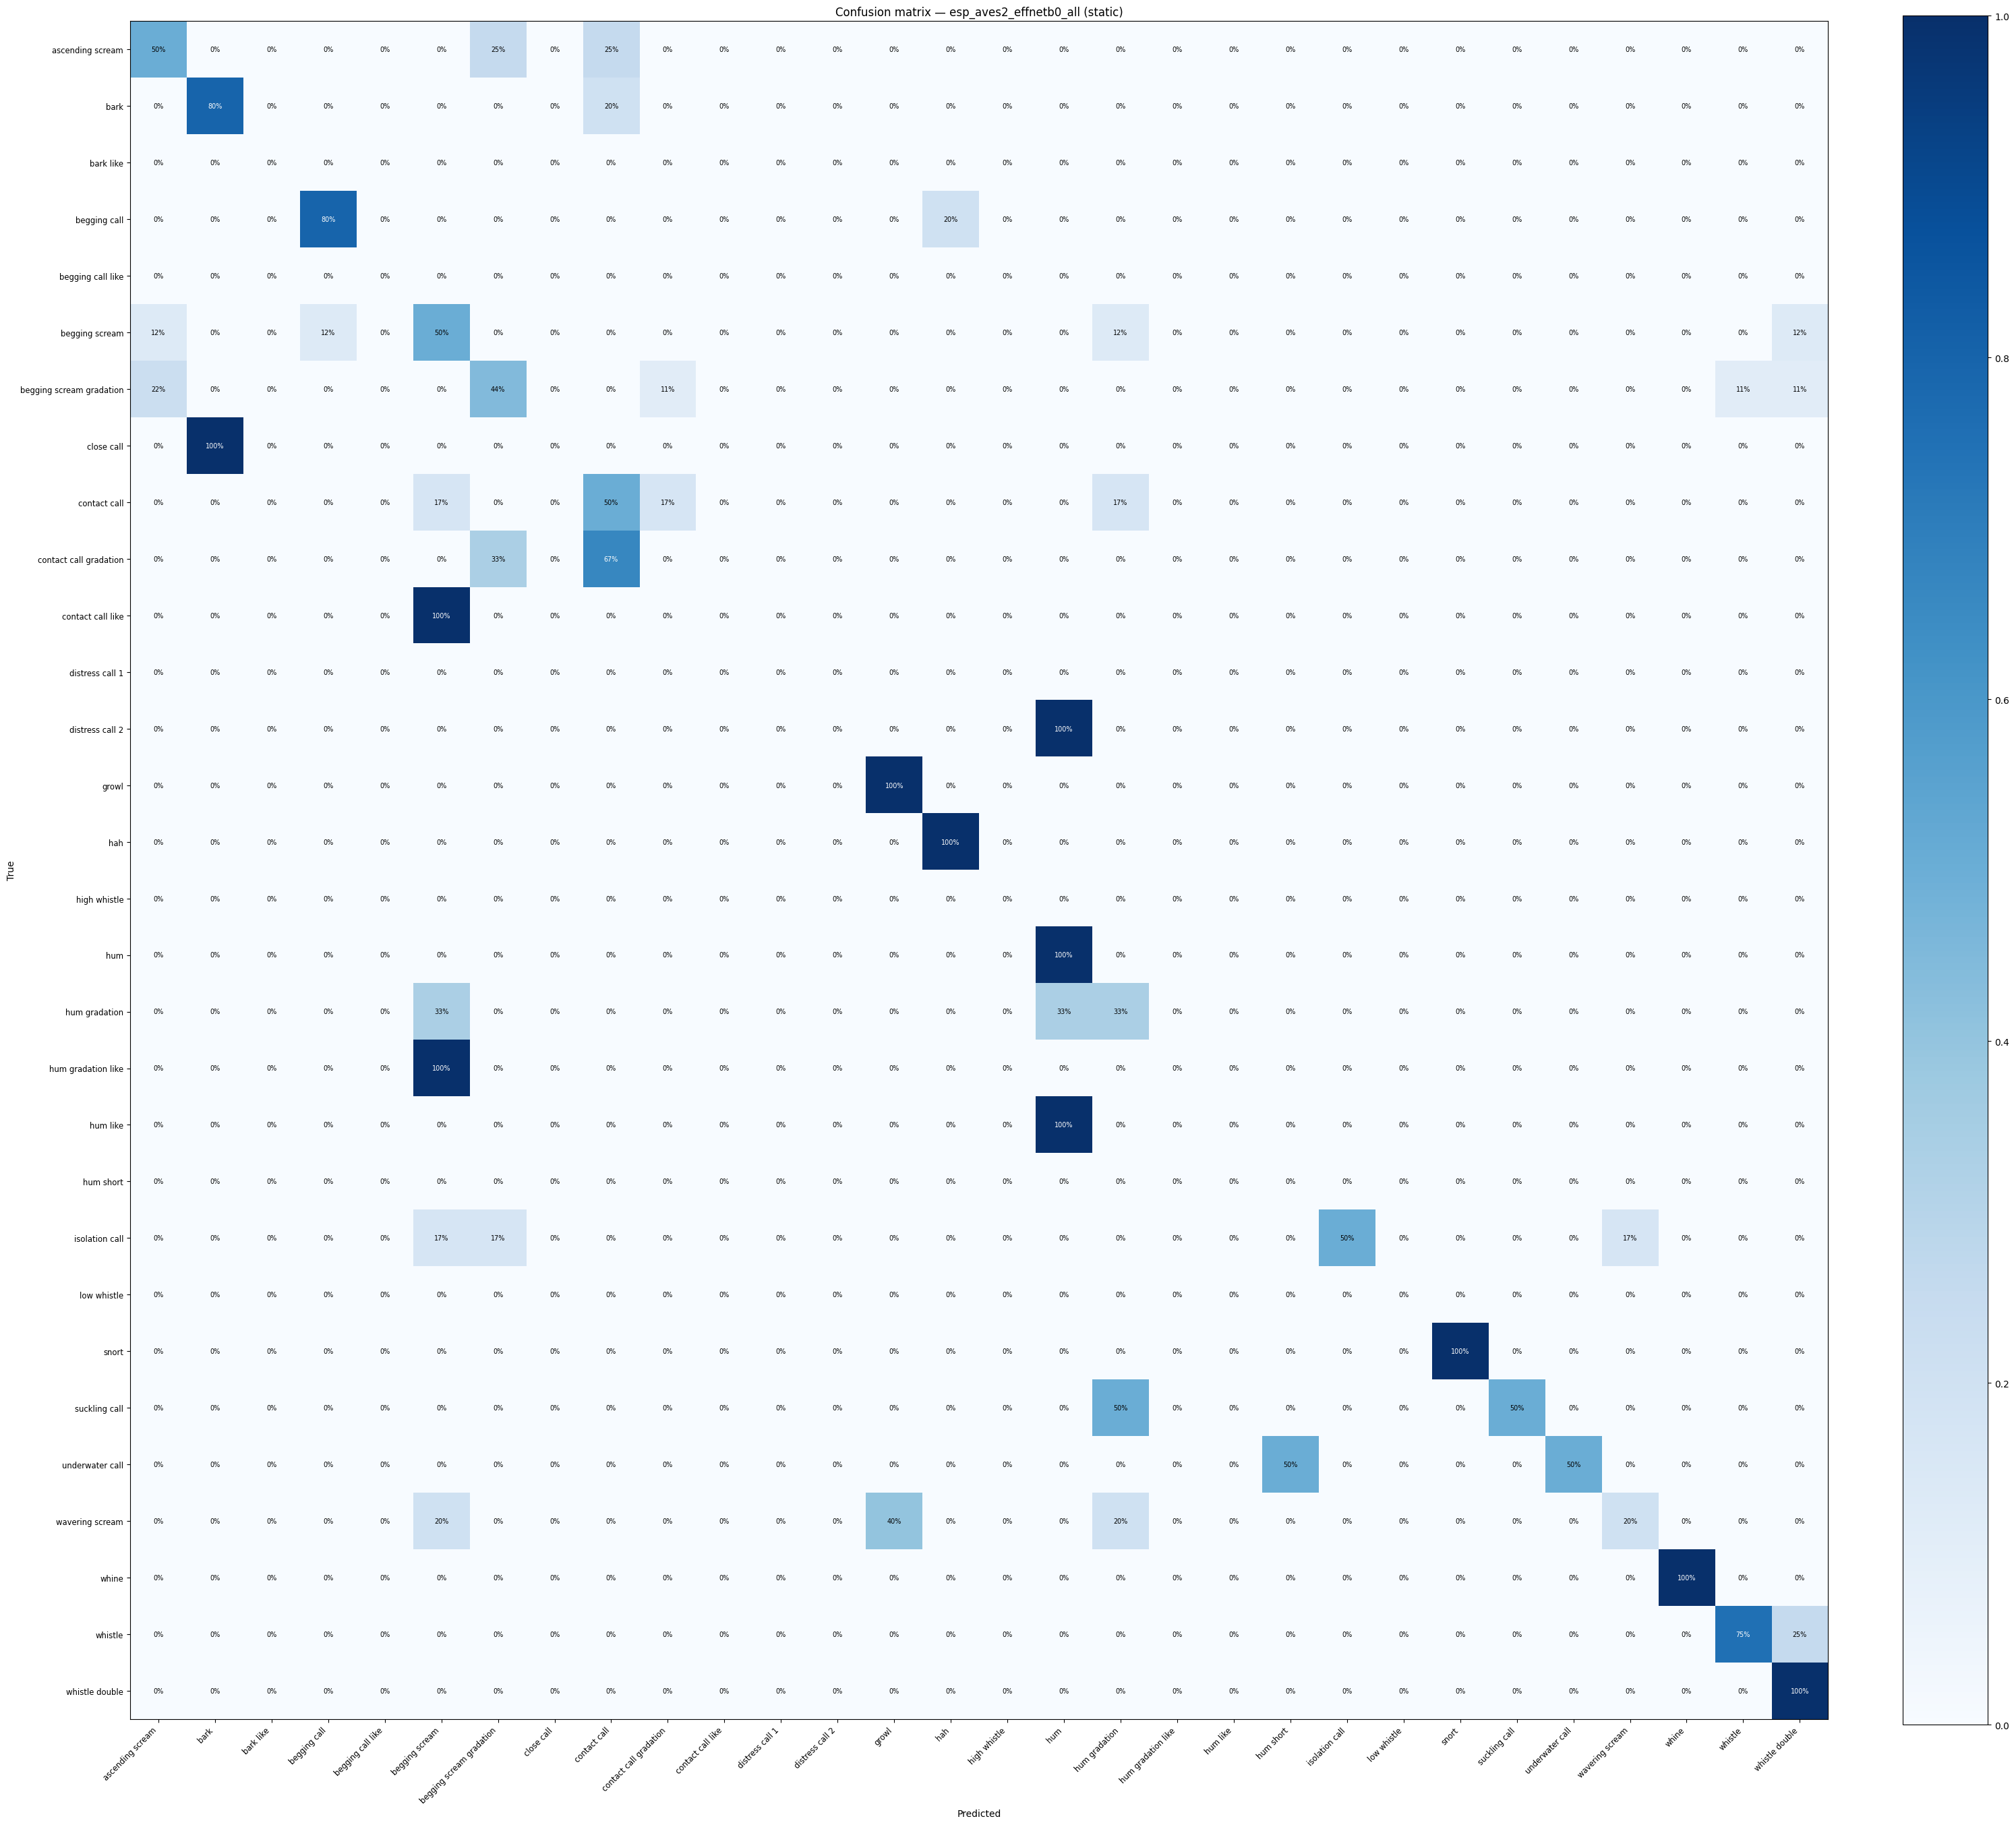

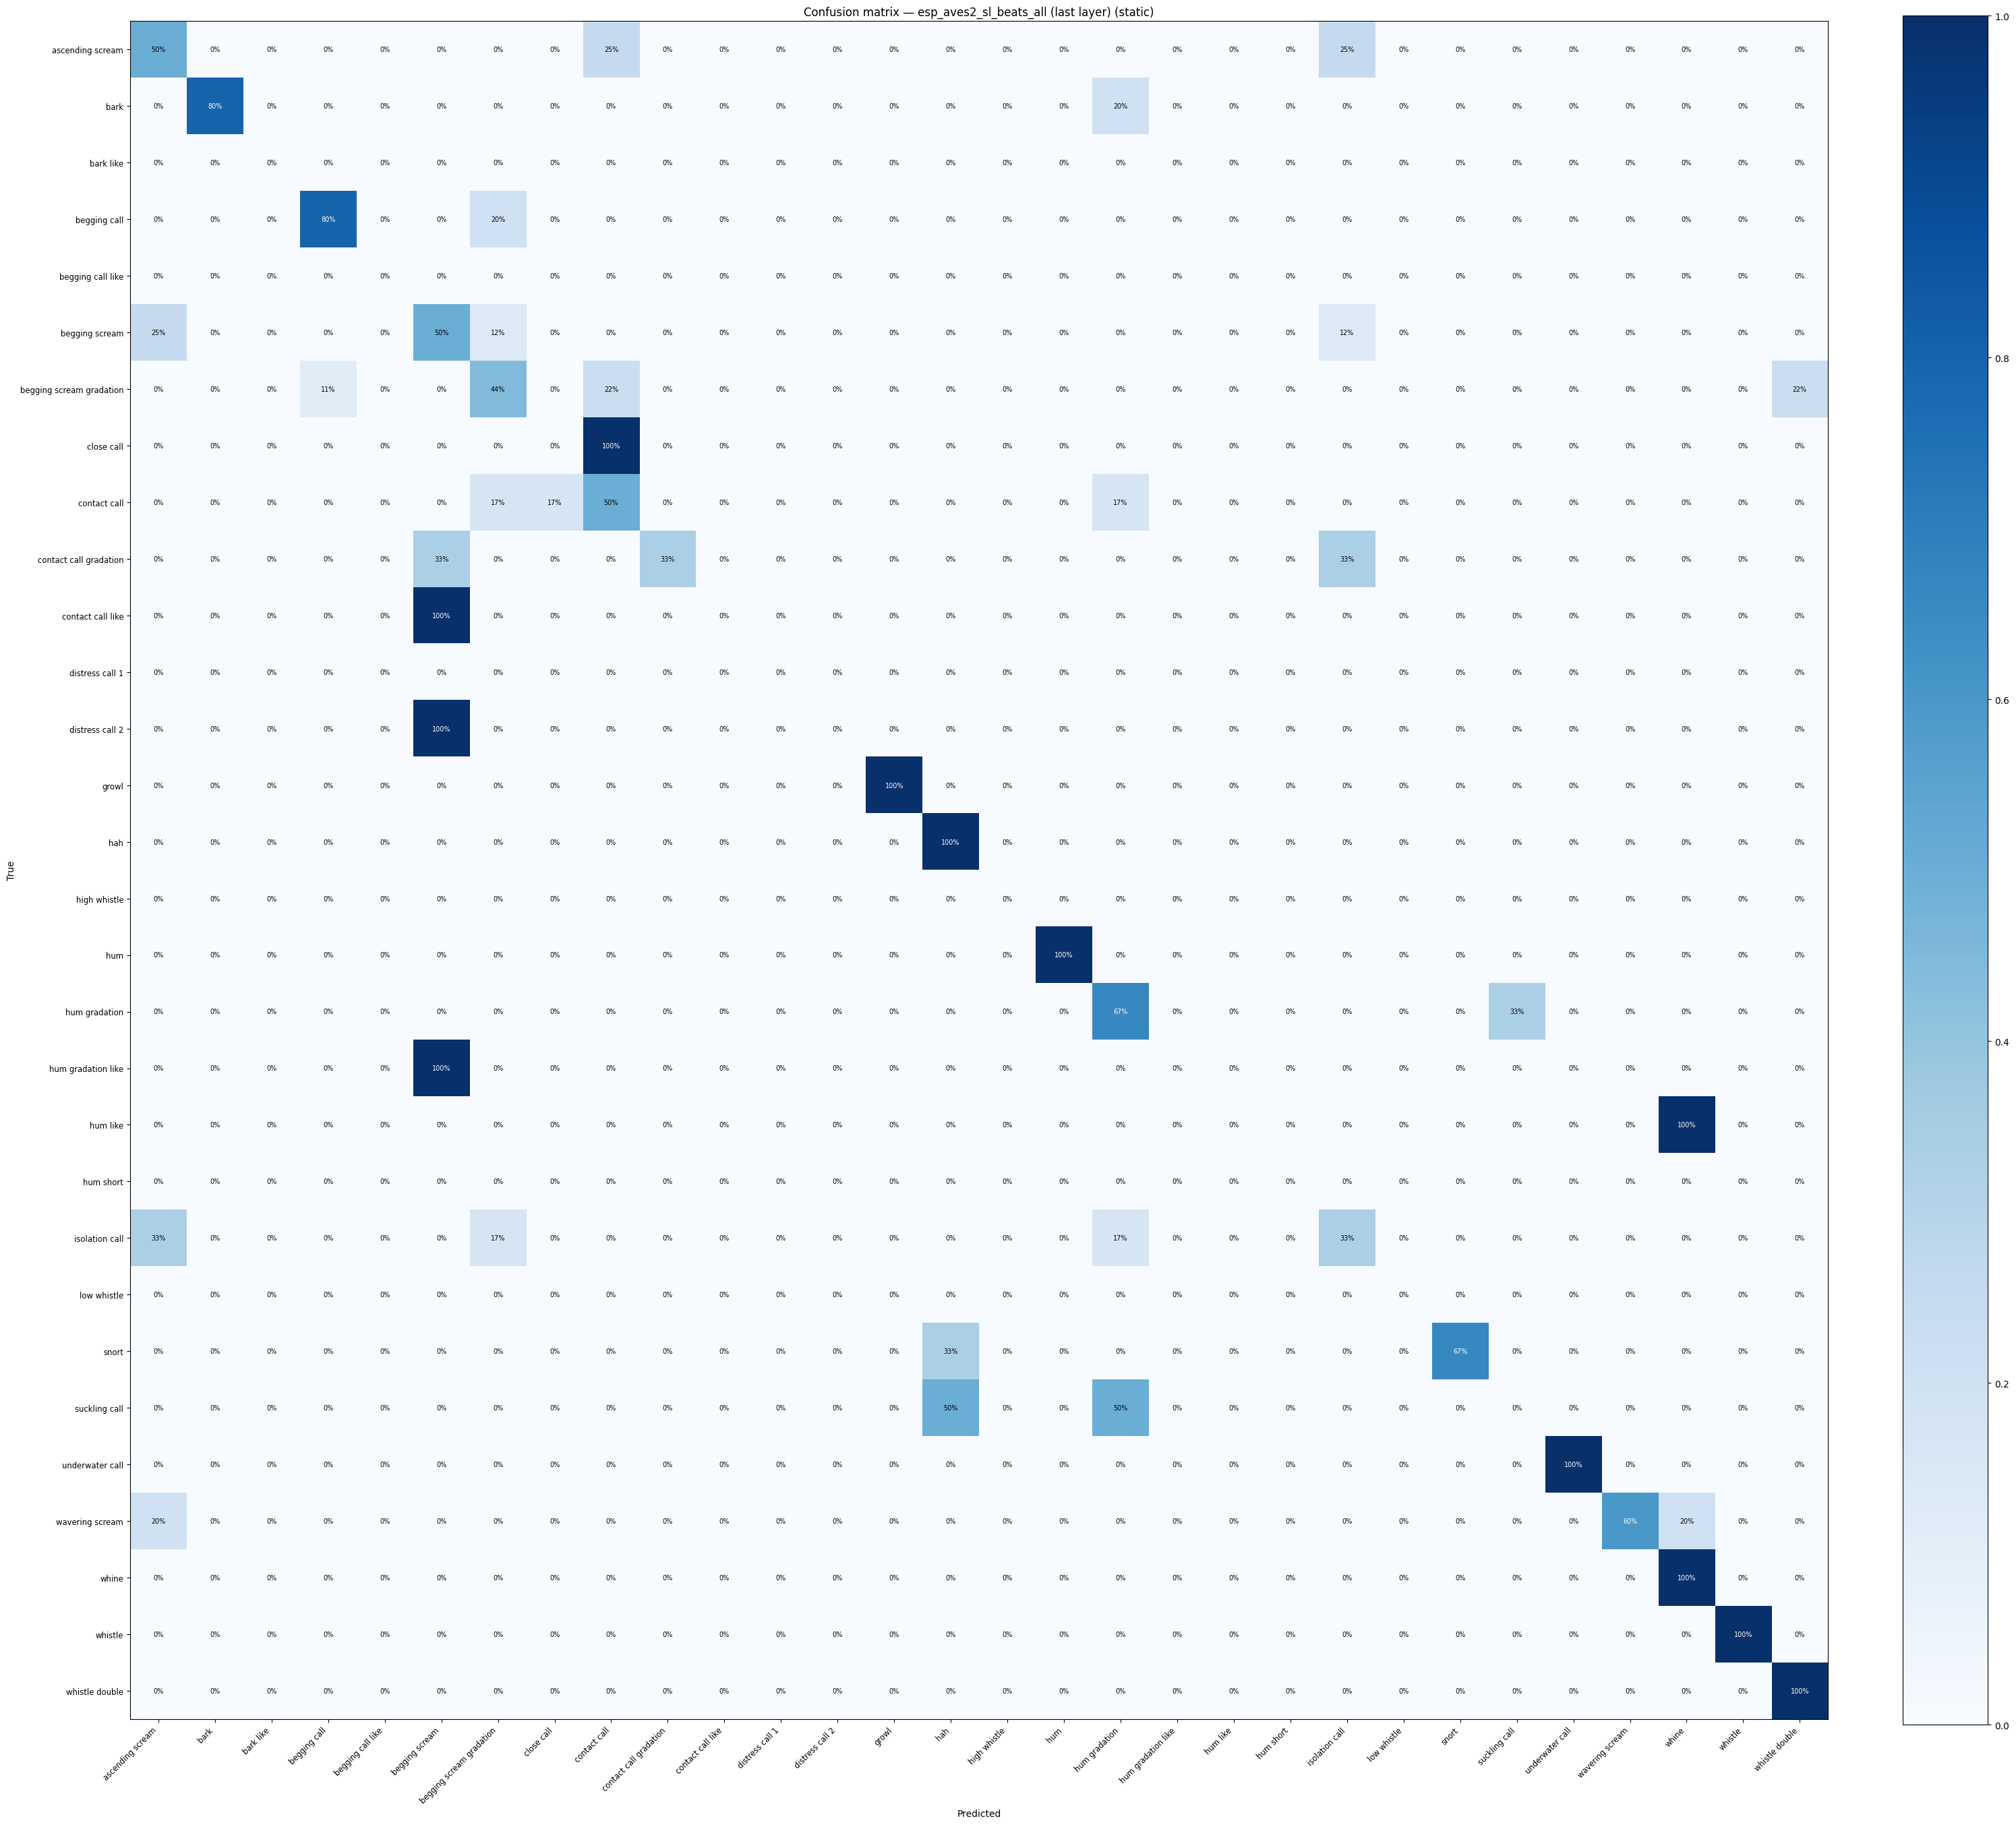

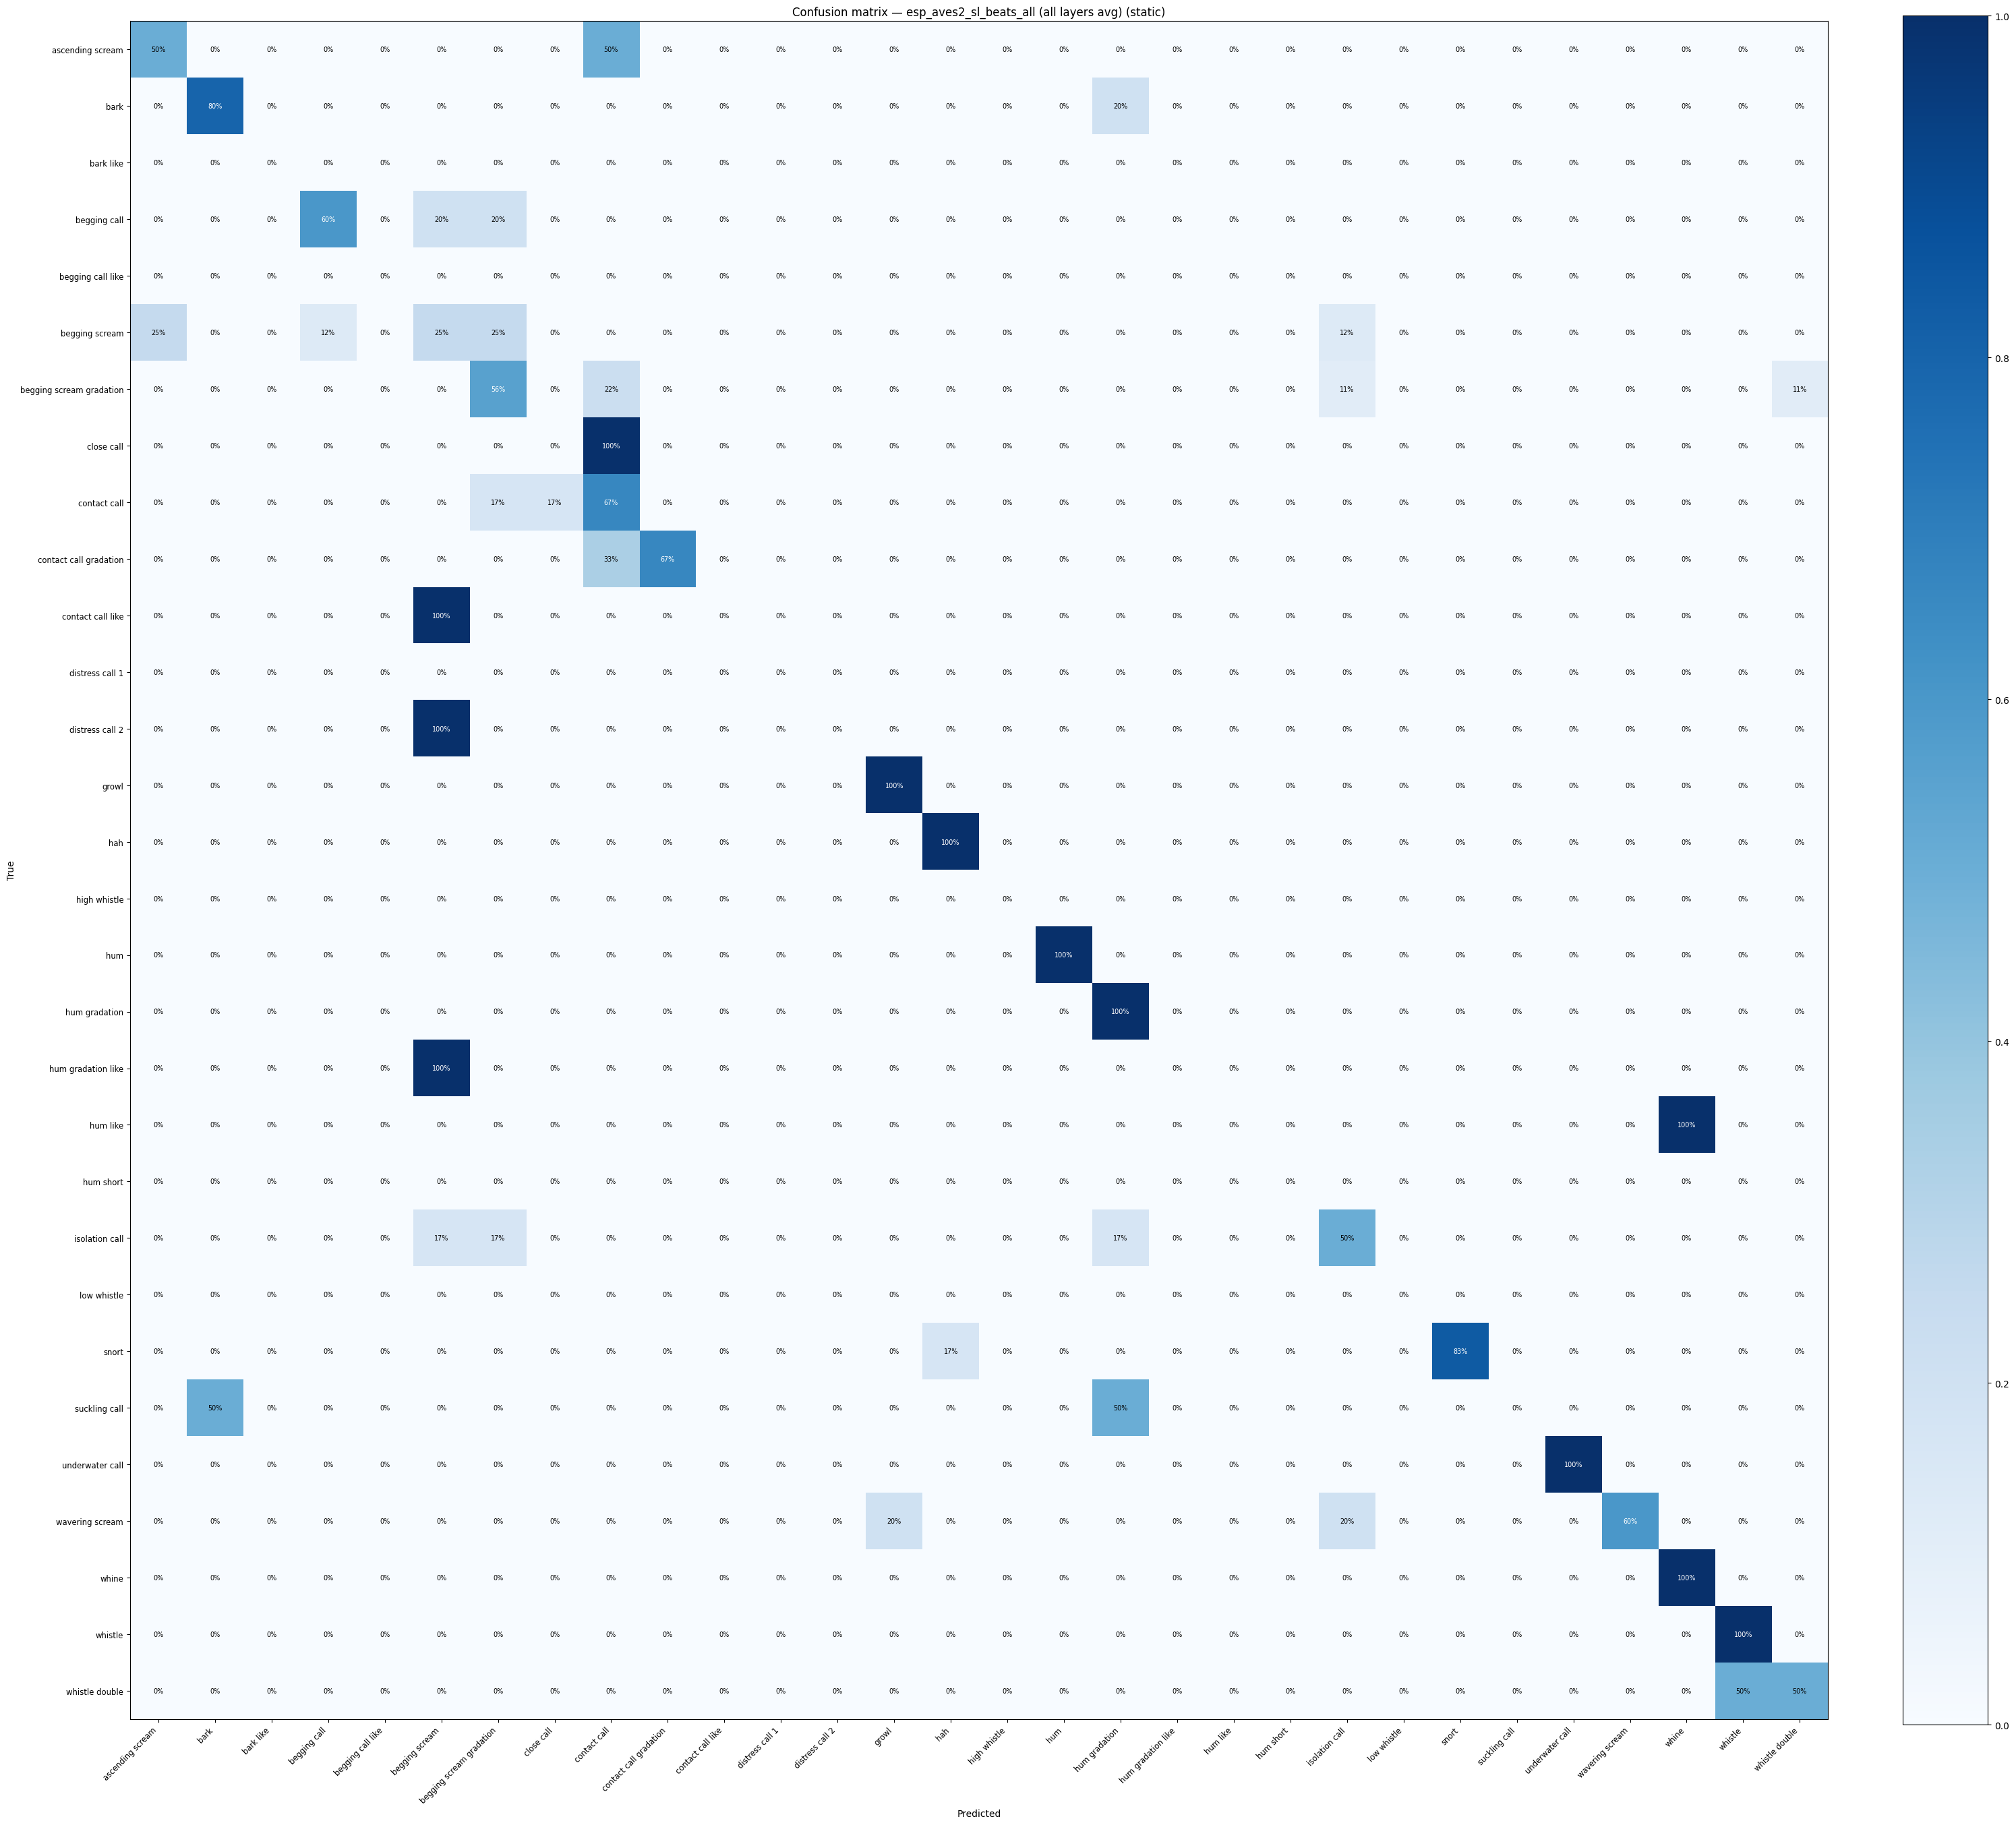

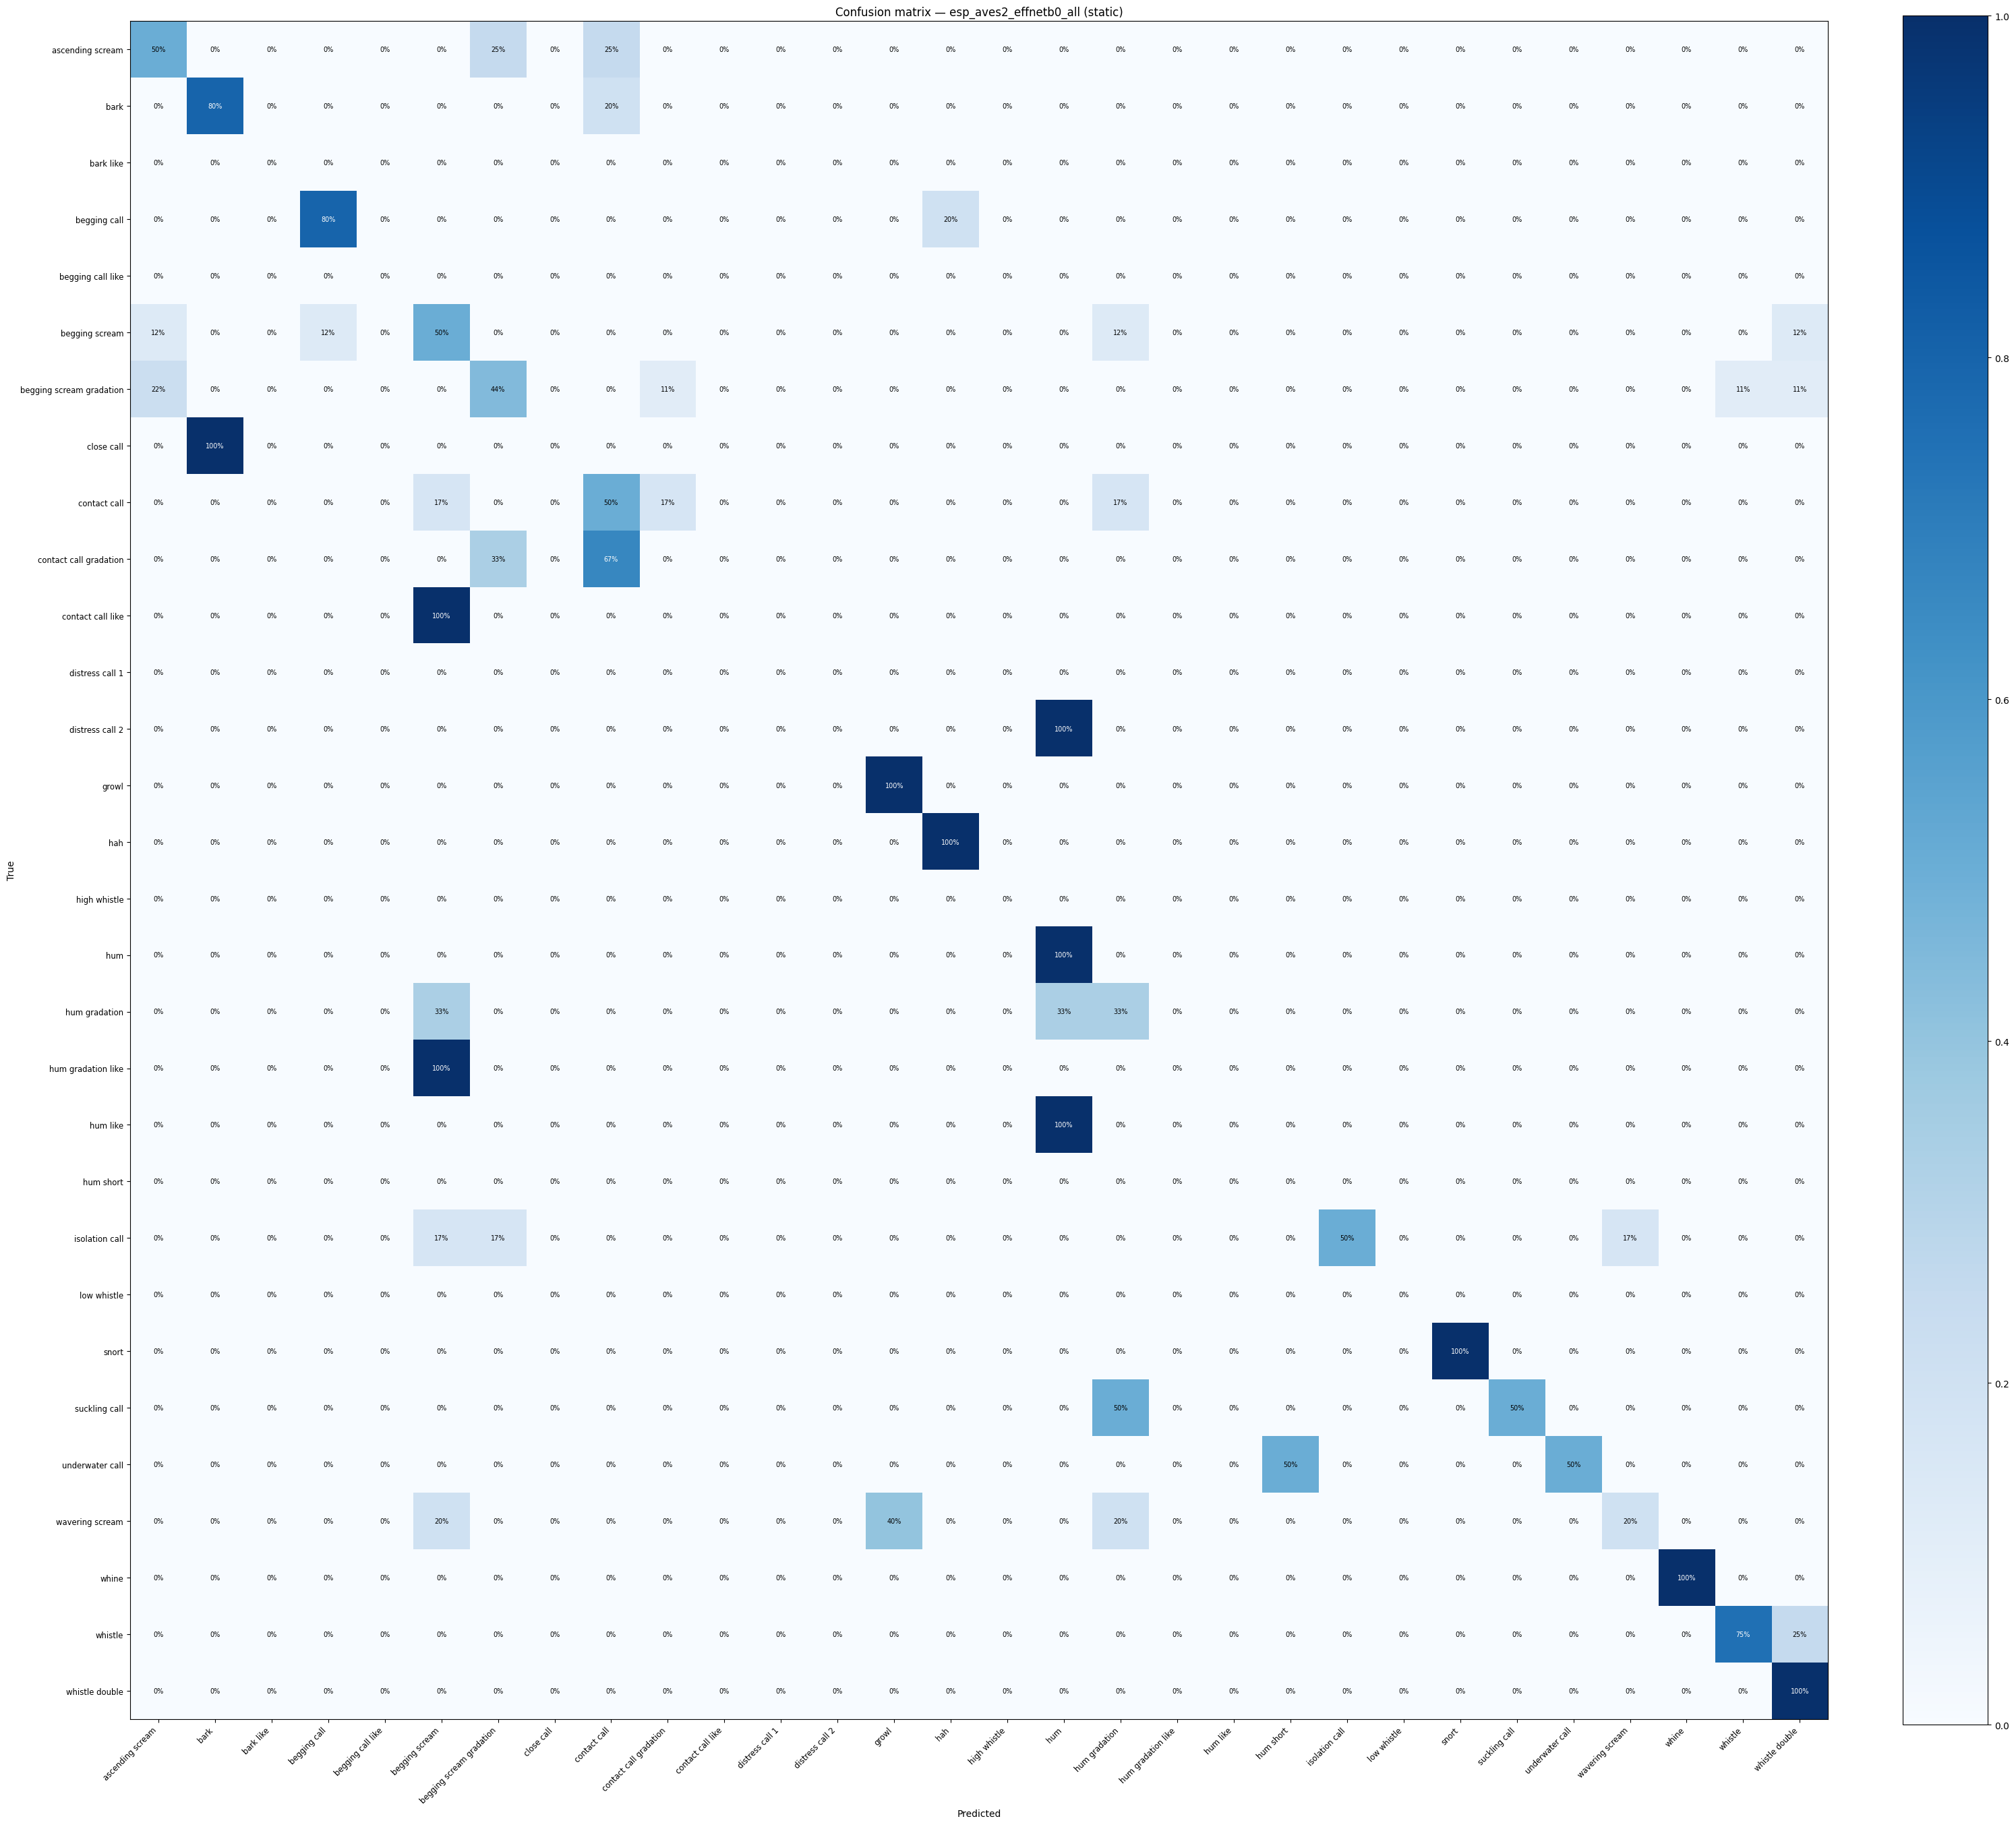

In [16]:
import plotly.figure_factory as ff


def confusion_heatmap(result: dict, model_name: str) -> go.Figure:
    cm = result["confusion_matrix"].astype(float)
    cm_norm = (cm / cm.sum(axis=1, keepdims=True) * 100).round(1)
    classes = result["classes"]
    fig = ff.create_annotated_heatmap(
        z=cm_norm.tolist(),
        x=classes,
        y=classes,
        colorscale="Blues",
        showscale=True,
        annotation_text=[[f"{v:.0f}%" for v in row] for row in cm_norm.tolist()],
    )
    fig.update_layout(
        title=f"Confusion matrix — {model_name}  (acc={result['accuracy']:.1%})",
        xaxis_title="Predicted",
        yaxis_title="True",
        height=700,
    )
    return fig


for name, res in probe_results.items():
    confusion_heatmap(res, name).show()
    display(
        confusion_heatmap_static(
            res["confusion_matrix"],
            res["classes"],
            title=f"Confusion matrix — {name} (static)",
        )
    )

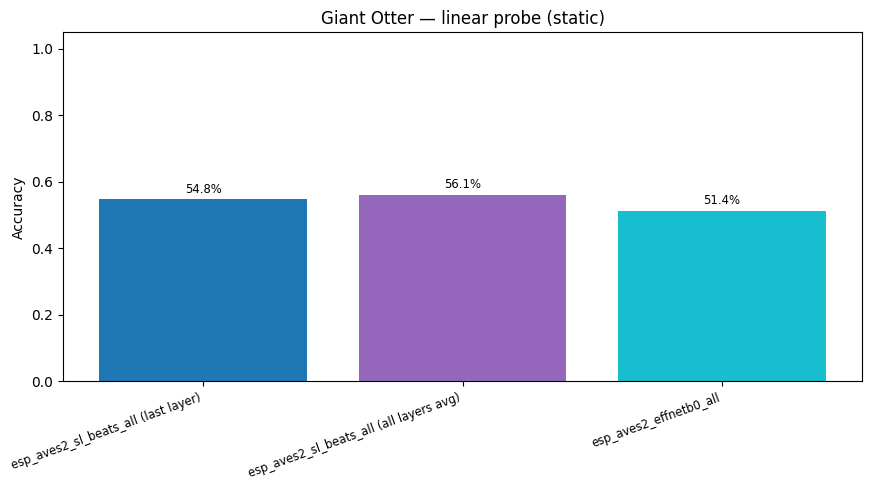

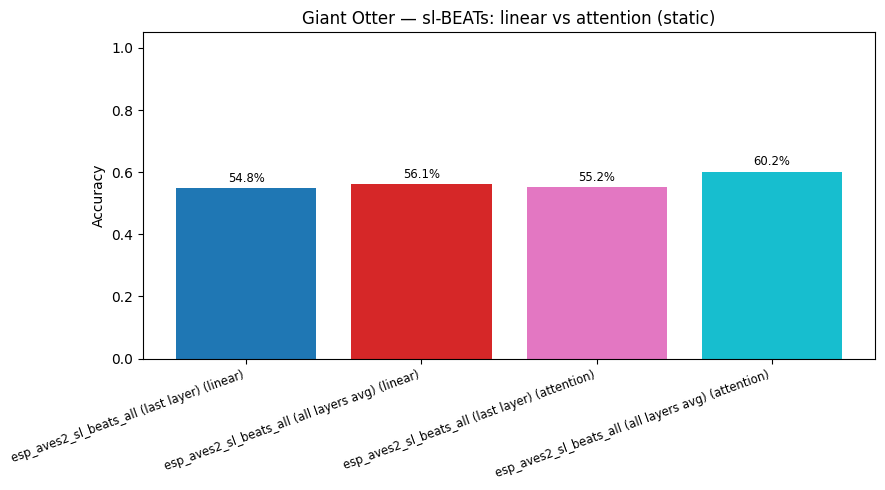

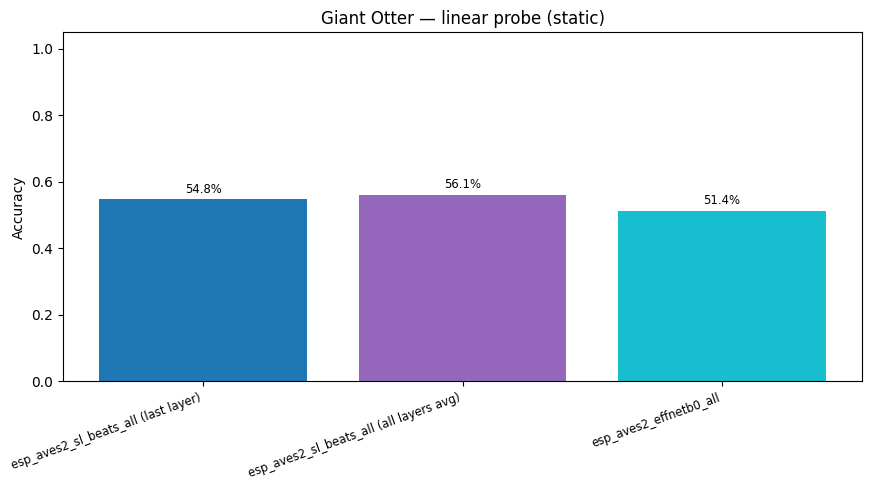

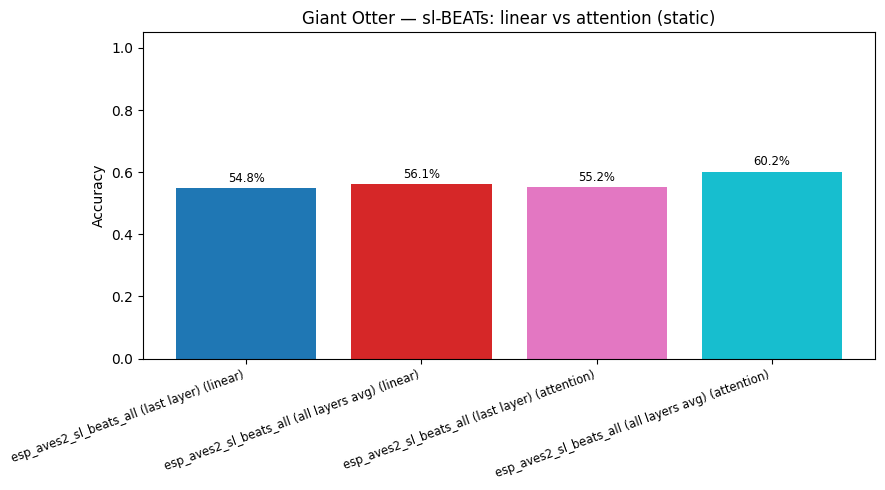

In [17]:
fig_cmp = plot_model_comparison(
    {k: v["accuracy"] for k, v in probe_results.items()},
    title="Giant Otter — call-type classification accuracy (linear probe)",
)
fig_cmp.show()
display(
    plot_model_comparison_static(
        {k: v["accuracy"] for k, v in probe_results.items()},
        title="Giant Otter — linear probe (static)",
    )
)

beats_attn_cmp = {}
for k, v in probe_results.items():
    if BEATS_MODEL in k:
        beats_attn_cmp[f"{k} (linear)"] = v["accuracy"]
for k, v in attention_results.items():
    beats_attn_cmp[f"{k} (attention)"] = v["accuracy"]
fig_cmp_beats = plot_model_comparison(
    beats_attn_cmp,
    title="Giant Otter — sl-BEATs: linear vs attention probe",
)
fig_cmp_beats.show()
display(
    plot_model_comparison_static(
        beats_attn_cmp,
        title="Giant Otter — sl-BEATs: linear vs attention (static)",
    )
)

## 9. Save Artifacts

In [21]:
ARTIFACTS_DIR = EXAMPLE_DIR / "artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

fig_beats.write_html(str(ARTIFACTS_DIR / "umap_beats.html"))
fig_beats_all.write_html(str(ARTIFACTS_DIR / "umap_beats_all_layers.html"))
fig_effnet.write_html(str(ARTIFACTS_DIR / "umap_effnet.html"))
fig_cmp.write_html(str(ARTIFACTS_DIR / "model_comparison.html"))
fig_cmp_beats.write_html(str(ARTIFACTS_DIR / "model_comparison_beats_attn.html"))

fig_counts_static.savefig(str(ARTIFACTS_DIR / "call_type_distribution_static.png"), dpi=150, bbox_inches="tight")
fig_umap_beats_static.savefig(str(ARTIFACTS_DIR / "umap_beats_static.png"), dpi=150, bbox_inches="tight")
fig_umap_beats_all_static.savefig(str(ARTIFACTS_DIR / "umap_beats_all_layers_static.png"), dpi=150, bbox_inches="tight")
fig_umap_effnet_static.savefig(str(ARTIFACTS_DIR / "umap_effnet_static.png"), dpi=150, bbox_inches="tight")
plt.close("all")

_metrics_out = {
    "n_files": len(files),
    "n_classes": len(set(labels)),
    "training_free": {
        k: compute_training_free_metrics(v, labels)
        for k, v in [("beats_last", beats_embs), ("beats_all_layers", beats_all_embs), ("effnet", effnet_embs)]
    },
    "linear_probe_accuracy": {k: round(v["accuracy"], 4) for k, v in probe_results.items()},
    "attention_probe_accuracy": {k: round(v["accuracy"], 4) for k, v in attention_results.items()},
}
with open(ARTIFACTS_DIR / "giant_otter_metrics.json", "w") as _f:
    json.dump(_metrics_out, _f, indent=2)
print(f"Artifacts saved to {ARTIFACTS_DIR}")

Artifacts saved to /home/marius_miron_earthspecies_org/code/avex-examples/examples/01_giant_otter_classifier/artifacts
